In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


### Import the raw data

In [2]:
df= pd.read_csv('../Data/Raw/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Analysis of the Initial Dataset

In [3]:
df.shape

(284807, 31)

In [4]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(1081)

In [8]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [9]:
df["Class"].value_counts(normalize=True)*100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

#### Observation so far

 All datatypes are floats(float64) with the exception of the target being an integer(int64).
 The shape of the dataset consist of (284807, 31)(row,columns),with zero null values and 1081 duplicates.The target variable is highly imbalanced, with fraudulent transactions representing approximately 0.173% of observations. This creates a significant class-imbalance problem that will need to be addressed during modeling. Techniques such as class weighting, undersampling, or SMOTE will be evaluated to determine which approach performs best
 

### Statistical profiling


In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [11]:
df["Class"].describe()

count    284807.000000
mean          0.001727
std           0.041527
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: Class, dtype: float64

In [12]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

In [13]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


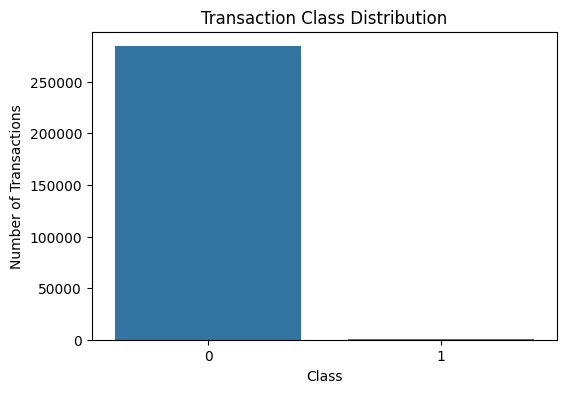

In [14]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="Class")

plt.title("Transaction Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

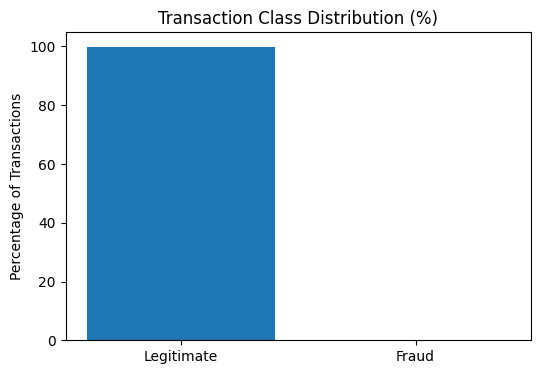

In [15]:
class_percentage = df["Class"].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))

plt.bar(
    ["Legitimate", "Fraud"],
    class_percentage.values
)

plt.title("Transaction Class Distribution (%)")
plt.ylabel("Percentage of Transactions")

plt.show()

In [16]:
fraud_percentage = df["Class"].mean() * 100

print(f"Fraud percentage: {fraud_percentage:.3f}%")

Fraud percentage: 0.173%


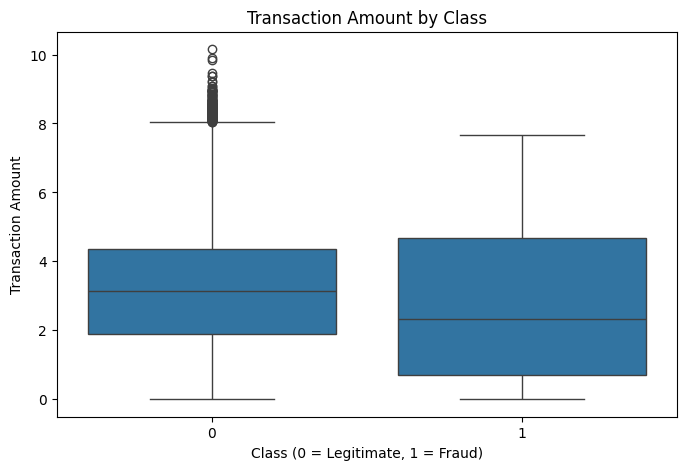

In [17]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y=np.log1p(df["Amount"])
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

In [18]:
df.groupby("Class")["Amount"].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

In [19]:
df.groupby("Class")["Amount"].median()

Class
0    22.00
1     9.25
Name: Amount, dtype: float64

In [20]:
amount_stats = df.groupby("Class")["Amount"].agg(["mean", "median"])

amount_stats["mean_median_ratio"] = (
    amount_stats["mean"] / amount_stats["median"]
)

amount_stats

,mean,median,mean_median_ratio
Class,,,
0,88.291022,22.00,4.013228
1,122.211321,9.25,13.212035


The fraudulent class has a higher mean transaction amount (122.21) but a lower median transaction amount (9.25) than the legitimate class (mean 88.29; median 22.00). This discrepancy suggests that the fraudulent transaction amount distribution is strongly right-skewed and may contain relatively large values that substantially affect its mean. Further distributional analysis is required before determining whether transaction amount is a useful fraud indicator.

In [21]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


In [22]:
df["Hour"] = (df["Time"] // 3600) % 24

In [23]:
df[["Time", "Hour", "Class"]].head()

,Time,Hour,Class
0,0.0,0.0,0
1,0.0,0.0,0
2,1.0,0.0,0
3,1.0,0.0,0
4,2.0,0.0,0


In [24]:
hourly_transactions = (
    df.groupby(["Hour", "Class"])
      .size()
      .reset_index(name="Count")
)

hourly_transactions.head()

,Hour,Class,Count
0,0.0,0,7689
1,0.0,1,6
2,1.0,0,4210
3,1.0,1,10
4,2.0,0,3271


In [25]:
hourly_fraud_rate = (
    df.groupby("Hour")["Class"]
      .mean()
      .mul(100)
)

hourly_fraud_rate

Hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64

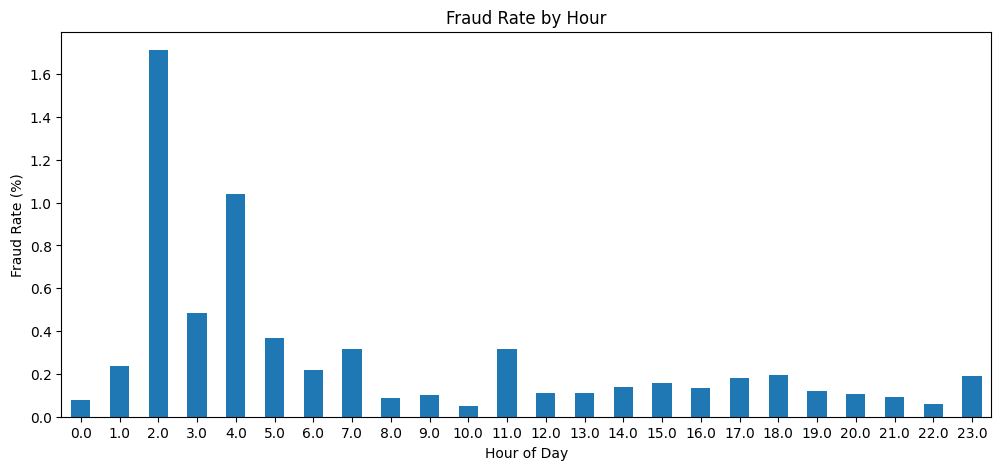

In [26]:
plt.figure(figsize=(12, 5))

hourly_fraud_rate.plot(
    kind="bar"
)

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=0)
plt.show()

In [27]:
hour_analysis = (
    df.groupby("Hour")
      .agg(
          transactions=("Class", "size"),
          fraud_transactions=("Class", "sum"),
          fraud_rate=("Class", "mean")
      )
)

hour_analysis["fraud_rate"] *= 100

hour_analysis

,transactions,fraud_transactions,fraud_rate
Hour,,,
0.0,7695,6,0.077973
1.0,4220,10,0.236967
2.0,3328,57,1.712740
3.0,3492,17,0.486827
4.0,2209,23,1.041195
5.0,2990,11,0.367893
6.0,4101,9,0.219459
7.0,7243,23,0.317548
8.0,10276,9,0.087583


In [28]:
hour_analysis.sort_values("fraud_rate", ascending=False)

,transactions,fraud_transactions,fraud_rate
Hour,,,
2.0,3328,57,1.712740
4.0,2209,23,1.041195
3.0,3492,17,0.486827
5.0,2990,11,0.367893
7.0,7243,23,0.317548
11.0,16856,53,0.314428
1.0,4220,10,0.236967
6.0,4101,9,0.219459
18.0,17039,33,0.193673


In [29]:
hour_analysis.sort_values("fraud_transactions", ascending=False)

,transactions,fraud_transactions,fraud_rate
Hour,,,
2.0,3328,57,1.712740
11.0,16856,53,0.314428
18.0,17039,33,0.193673
17.0,16166,29,0.179389
15.0,16461,26,0.157949
4.0,2209,23,1.041195
7.0,7243,23,0.317548
14.0,16570,23,0.138805
16.0,16453,22,0.133714


In [30]:
df["TimeBin"] = pd.cut(
    df["Time"],
    bins=20
)

time_fraud = (
    df.groupby("TimeBin", observed=True)["Class"]
      .agg(
          transactions="size",
          fraud_transactions="sum",
          fraud_rate="mean"
      )
)

time_fraud["fraud_rate"] *= 100

time_fraud

,transactions,fraud_transactions,fraud_rate
TimeBin,,,
"(-172.792, 8639.6]",6830,20,0.292826
"(8639.6, 17279.2]",3680,22,0.597826
"(17279.2, 25918.8]",4185,19,0.454002
"(25918.8, 34558.4]",12770,29,0.227095
"(34558.4, 43198.0]",19932,56,0.280955
"(43198.0, 51837.6]",18594,23,0.123696
"(51837.6, 60477.2]",18833,35,0.185844
"(60477.2, 69116.8]",19717,28,0.142009
"(69116.8, 77756.4]",21140,28,0.132450


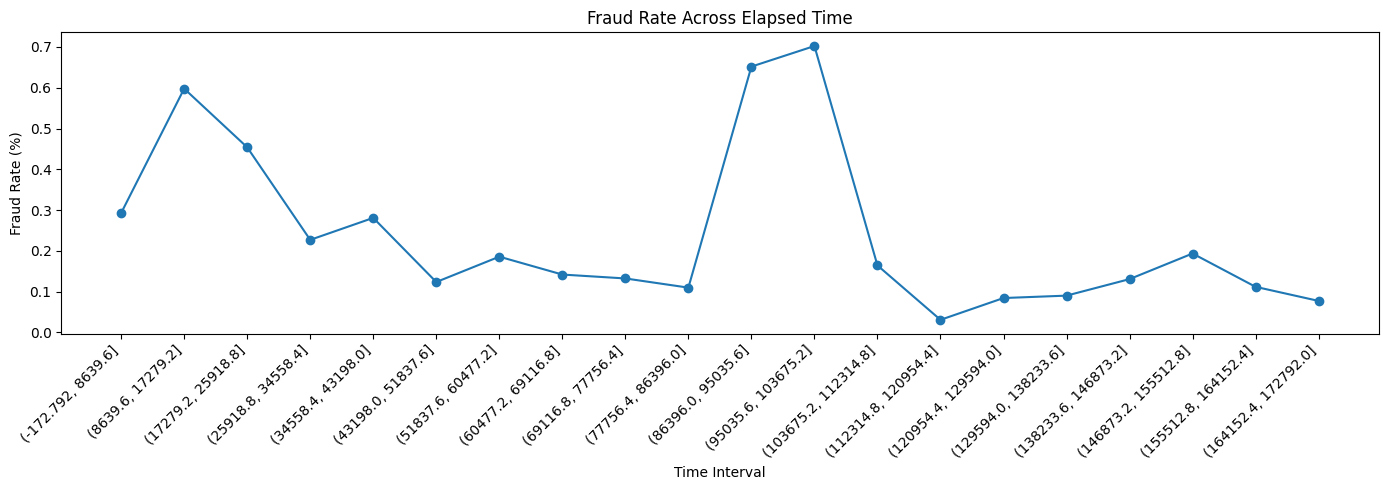

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(
    range(len(time_fraud)),
    time_fraud["fraud_rate"],
    marker="o"
)

plt.title("Fraud Rate Across Elapsed Time")
plt.xlabel("Time Interval")
plt.ylabel("Fraud Rate (%)")
plt.xticks(
    range(len(time_fraud)),
    [str(interval) for interval in time_fraud.index],
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

In [32]:
v_features = [col for col in df.columns if col.startswith("V")]

fraud_means = df.groupby("Class")[v_features].mean().T

fraud_means

Class,0,1
V1,0.008258,-4.771948
V2,-0.006271,3.623778
V3,0.012171,-7.033281
V4,-0.007860,4.542029
V5,0.005453,-3.151225
V6,0.002419,-1.397737
V7,0.009637,-5.568731
V8,-0.000987,0.570636
V9,0.004467,-2.581123
V10,0.009824,-5.676883


In [33]:
mean_difference = (
    df.groupby("Class")[v_features]
      .mean()
      .T
)

mean_difference["absolute_difference"] = (
    mean_difference[1] - mean_difference[0]
).abs()

mean_difference.sort_values(
    "absolute_difference",
    ascending=False
)

Class,0,1,absolute_difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


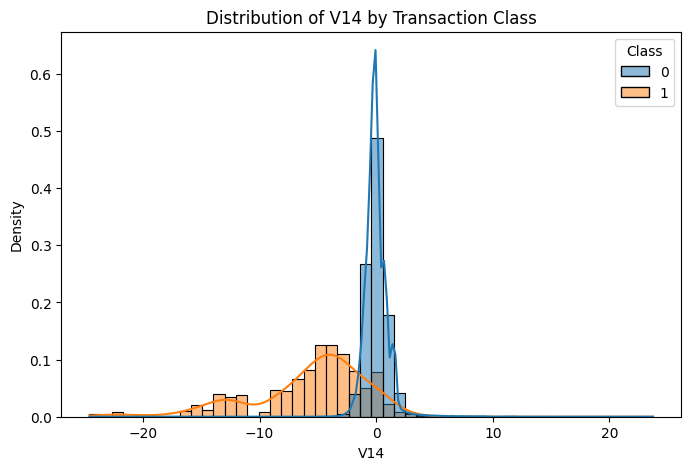

In [34]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="V10",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of V14 by Transaction Class")
plt.xlabel("V14")
plt.ylabel("Density")

plt.show()

In [35]:
feature_summary = df.groupby("Class")[v_features].agg(
    ["mean", "median", "std"]
).T

feature_summary

Class              0         1
V1  mean    0.008258 -4.771948
    median  0.020023 -2.342497
    std     1.929814  6.783687
V2  mean   -0.006271  3.623778
    median  0.064070  2.717869
...              ...       ...
V27 median  0.001230  0.394926
    std     0.399847  1.376766
V28 mean   -0.000131  0.075667
    median  0.011199  0.146344
    std     0.329570  0.547291

[84 rows x 2 columns]

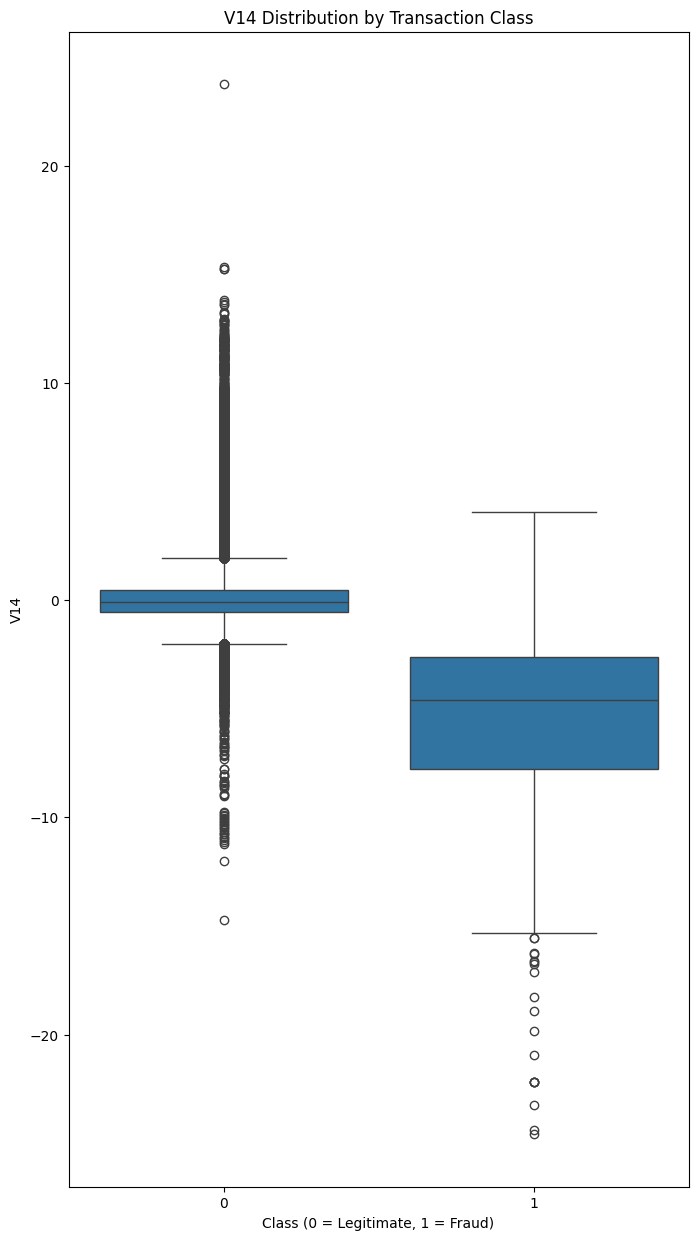

In [36]:
plt.figure(figsize=(8, 15))

sns.boxplot(
    data=df,
    x="Class",
    y="V10"
)

plt.title("V14 Distribution by Transaction Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V14")

plt.show()

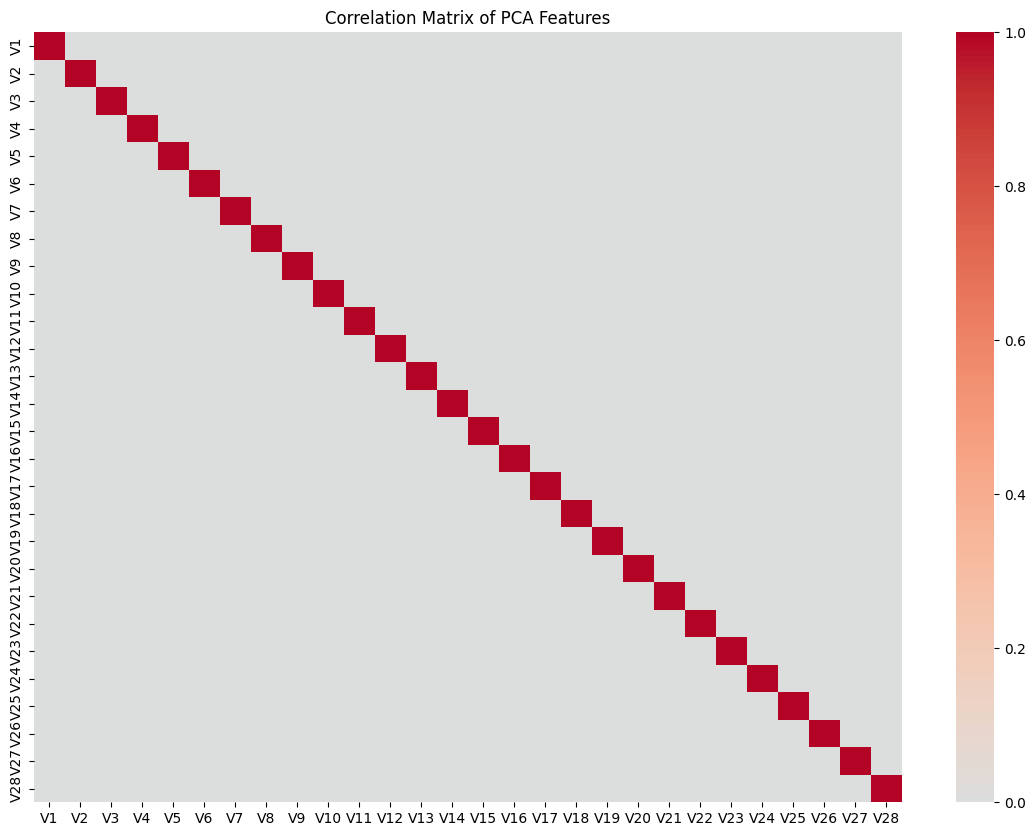

In [37]:
plt.figure(figsize=(14, 10))

correlation_matrix = df[v_features].corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of PCA Features")

plt.show()

In [38]:
target_correlation = (
    df[v_features + ["Class"]]
    .corr()["Class"]
    .drop("Class")
    .sort_values()
)

target_correlation

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
V5    -0.094974
V6    -0.043643
V24   -0.007221
V13   -0.004570
V15   -0.004223
V23   -0.002685
V22    0.000805
V25    0.003308
V26    0.004455
V28    0.009536
V27    0.017580
V8     0.019875
V20    0.020090
V19    0.034783
V21    0.040413
V2     0.091289
V4     0.133447
V11    0.154876
Name: Class, dtype: float64

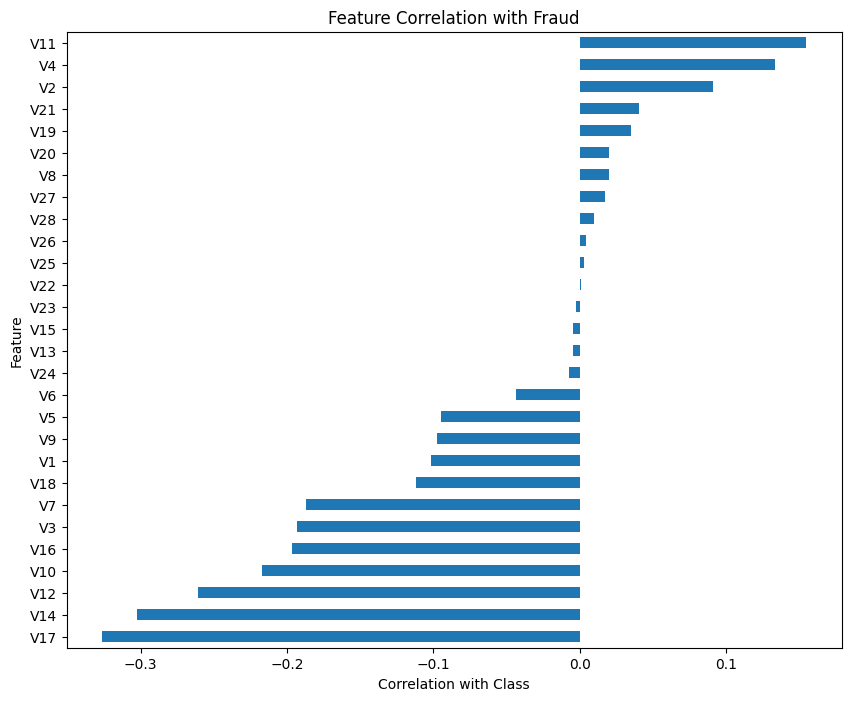

In [39]:
plt.figure(figsize=(10, 8))

target_correlation.plot(kind="barh")

plt.title("Feature Correlation with Fraud")
plt.xlabel("Correlation with Class")
plt.ylabel("Feature")

plt.show()

In [40]:
mean_difference.sort_values(
    "absolute_difference",
    ascending=False
)

Class,0,1,absolute_difference
V3,0.012171,-7.033281,7.045452
V14,0.012064,-6.971723,6.983787
V17,0.011535,-6.665836,6.677371
V12,0.010832,-6.259393,6.270225
V10,0.009824,-5.676883,5.686707
V7,0.009637,-5.568731,5.578368
V1,0.008258,-4.771948,4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,4.147110
V11,-0.006576,3.800173,3.806749


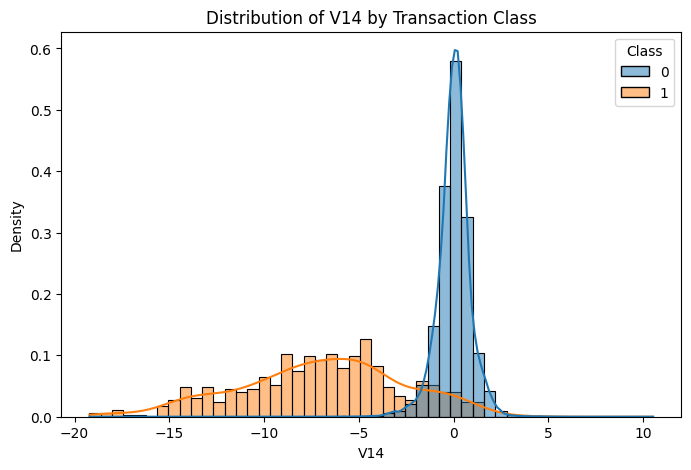

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="V14",
    hue="Class",
    bins=50,
    kde=True,
    stat="density",
    common_norm=False
)

plt.title("Distribution of V14 by Transaction Class")
plt.xlabel("V14")
plt.ylabel("Density")

plt.show()

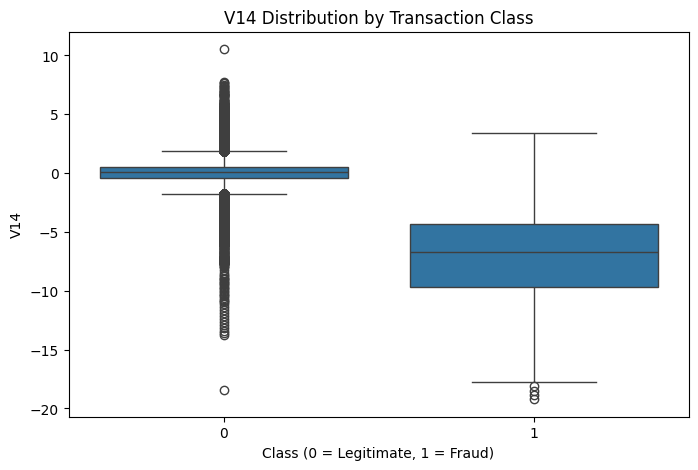

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="V14"
)

plt.title("V14 Distribution by Transaction Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("V14")

plt.show()

In [43]:
corr_matrix = df[v_features].corr()

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=abs, ascending=False)
)

corr_pairs.head(15)

V12  V13   -2.321486e-14
V17  V18   -4.894901e-15
V9   V14    3.784757e-15
V21  V22    3.649908e-15
V25  V26    2.646517e-15
V18  V19   -2.499138e-15
V16  V17    2.482413e-15
     V18   -2.420915e-15
V14  V28    2.289427e-15
V9   V13    2.251072e-15
V5   V16    2.246261e-15
V13  V14    2.161967e-15
V1   V28    2.083082e-15
V6   V11    1.980503e-15
V11  V24    1.933267e-15
dtype: float64

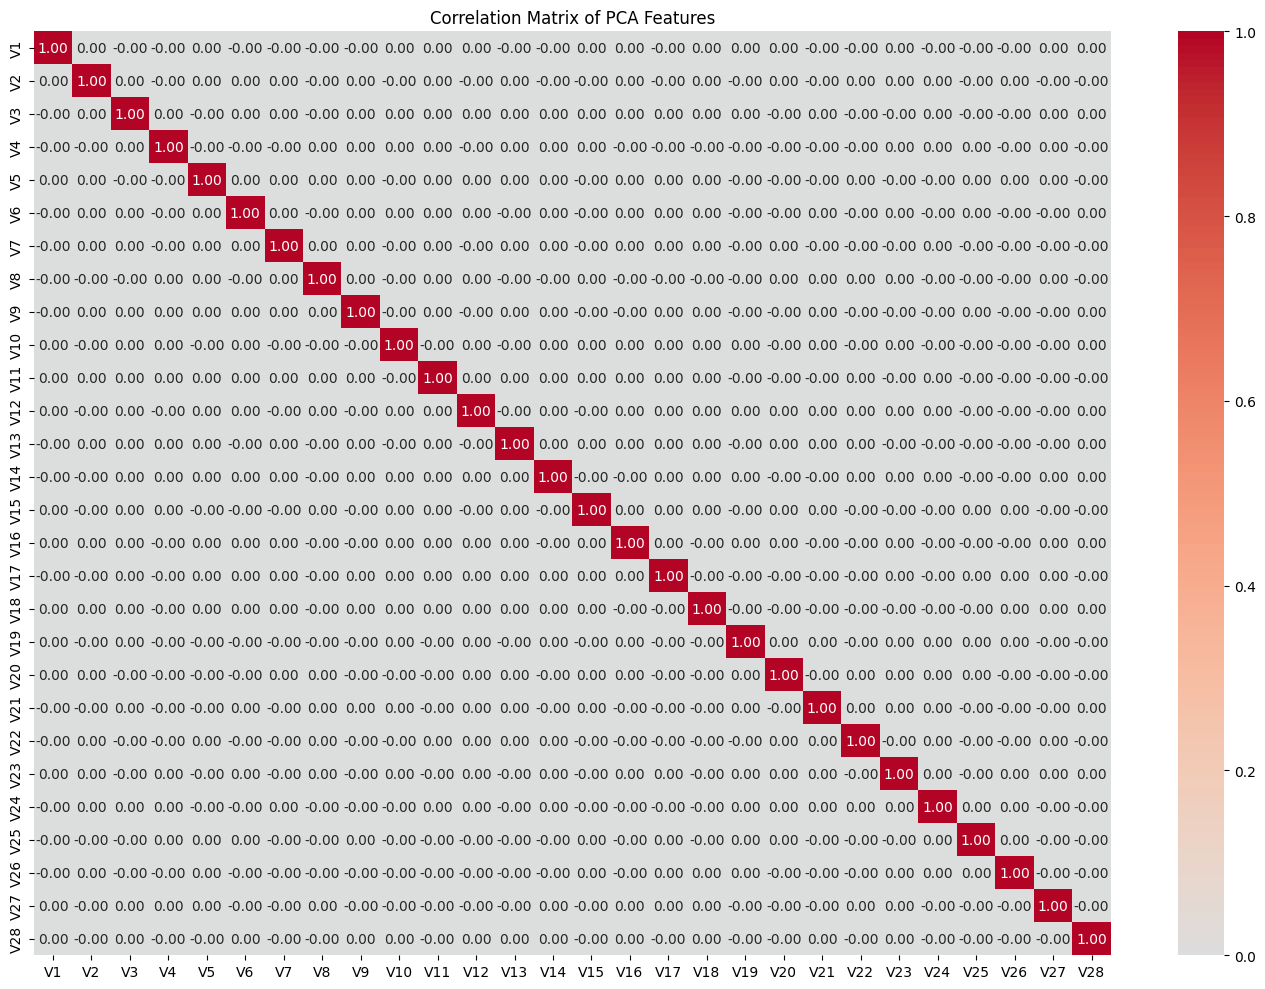

In [44]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of PCA Features")
plt.tight_layout()
plt.show()

In [45]:
feature_stats = df.describe().T

feature_stats[["mean", "std", "min", "25%", "50%", "75%", "max"]]

,mean,std,min,25%,50%,75%,max
Time,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [46]:
feature_ranges = pd.DataFrame({
    "min": df[v_features].min(),
    "max": df[v_features].max(),
})

feature_ranges["range"] = (
    feature_ranges["max"] - feature_ranges["min"]
)

feature_ranges.sort_values(
    "range",
    ascending=False
)

,min,max,range
V7,-43.557242,120.589494,164.146736
V5,-113.743307,34.801666,148.544973
V6,-26.160506,73.301626,99.462131
V2,-72.715728,22.057729,94.773457
V20,-54.497720,39.420904,93.918625
V8,-73.216718,20.007208,93.223927
V23,-44.807735,22.528412,67.336147
V21,-34.830382,27.202839,62.033221
V1,-56.407510,2.454930,58.862440
V3,-48.325589,9.382558,57.708148


In [47]:
skewness = df[v_features + ["Amount"]].skew()

skewness.sort_values(
    key=abs,
    ascending=False
)

Amount    16.977724
V28       11.192091
V8        -8.521944
V23       -5.875140
V2        -4.624866
V17       -3.844914
V21        3.592991
V1        -3.280667
V7         2.553907
V5        -2.425901
V12       -2.278401
V3        -2.240155
V20       -2.037155
V14       -1.995176
V6         1.826581
V10        1.187141
V27       -1.170209
V16       -1.100966
V4         0.676292
V26        0.576693
V9         0.554680
V24       -0.552499
V25       -0.415793
V11        0.356506
V15       -0.308423
V18       -0.259880
V22       -0.213258
V19        0.109192
V13        0.065233
dtype: float64

In [48]:
duplicate_rows = df[df.duplicated(keep=False)]

duplicate_rows["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [49]:
duplicate_class_summary = (
    duplicate_rows
    .groupby("Class")
    .size()
)

duplicate_class_summary

Class
0    1822
1      32
dtype: int64

In [50]:
print("Total duplicate rows:", df.duplicated().sum())
print("Duplicate rows including first occurrence:", df.duplicated(keep=False).sum())

Total duplicate rows: 1081
Duplicate rows including first occurrence: 1854


In [51]:
feature_cols = [col for col in df.columns if col != "Class"]

# Create a hash for each transaction's features
row_hash = pd.util.hash_pandas_object(
    df[feature_cols],
    index=False
)

# Keep only duplicated feature rows
dup_mask = row_hash.duplicated(keep=False)

dup_df = df.loc[dup_mask, ["Class"]].copy()
dup_df["_hash"] = row_hash.loc[dup_mask].values

# Check whether the same feature combination has different Class labels
conflicts = dup_df.groupby("_hash")["Class"].nunique()

print("Duplicate groups:", len(conflicts))
print("Groups with conflicting labels:", (conflicts > 1).sum())

Duplicate groups: 773
Groups with conflicting labels: 0


In [52]:
df_clean = df.drop_duplicates().copy()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", len(df) - len(df_clean))

Original shape: (284807, 33)
Cleaned shape: (283726, 33)
Rows removed: 1081


In [53]:
print("Remaining duplicates:", df_clean.duplicated().sum())

Remaining duplicates: 0


In [54]:
print(df_clean["Class"].value_counts())
print(df_clean["Class"].value_counts(normalize=True) * 100)

Class
0    283253
1       473
Name: count, dtype: int64
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [55]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 33 columns):
 #   Column   Non-Null Count   Dtype   
---  ------   --------------   -----   
 0   Time     283726 non-null  float64 
 1   V1       283726 non-null  float64 
 2   V2       283726 non-null  float64 
 3   V3       283726 non-null  float64 
 4   V4       283726 non-null  float64 
 5   V5       283726 non-null  float64 
 6   V6       283726 non-null  float64 
 7   V7       283726 non-null  float64 
 8   V8       283726 non-null  float64 
 9   V9       283726 non-null  float64 
 10  V10      283726 non-null  float64 
 11  V11      283726 non-null  float64 
 12  V12      283726 non-null  float64 
 13  V13      283726 non-null  float64 
 14  V14      283726 non-null  float64 
 15  V15      283726 non-null  float64 
 16  V16      283726 non-null  float64 
 17  V17      283726 non-null  float64 
 18  V18      283726 non-null  float64 
 19  V19      283726 non-null  float64 
 20  V20      

In [56]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,283726.0,94811.077600,47481.047891,0.000000,54204.750000,84692.500000,139298.000000,172792.000000
V1,283726.0,0.005917,1.948026,-56.407510,-0.915951,0.020384,1.316068,2.454930
V2,283726.0,-0.004135,1.646703,-72.715728,-0.600321,0.063949,0.800283,22.057729
V3,283726.0,0.001613,1.508682,-48.325589,-0.889682,0.179963,1.026960,9.382558
V4,283726.0,-0.002966,1.414184,-5.683171,-0.850134,-0.022248,0.739647,16.875344
V5,283726.0,0.001828,1.377008,-113.743307,-0.689830,-0.053468,0.612218,34.801666
V6,283726.0,-0.001139,1.331931,-26.160506,-0.769031,-0.275168,0.396792,73.301626
V7,283726.0,0.001801,1.227664,-43.557242,-0.552509,0.040859,0.570474,120.589494
V8,283726.0,-0.000854,1.179054,-73.216718,-0.208828,0.021898,0.325704,20.007208
V9,283726.0,-0.001596,1.095492,-13.434066,-0.644221,-0.052596,0.595977,15.594995


In [57]:
df_clean["Hour"] = (df_clean["Time"] // 3600) % 24

In [58]:
df_clean.to_csv(
    "../data/processed/creditcard_clean.csv",
    index=False
)

In [59]:
import os

print(os.path.exists("../data/processed/creditcard_clean.csv"))

True
